# Stage 3 — Residual-Based Anomaly Detection

Trains a LightGBM baseline model on the cleaned feature matrix from Stage 2 and scores anomalies as readings whose per-building residual z-score exceeds a threshold.

**Approach:**
1. Train LightGBM on clean data (Jan–Jul 2016) to predict expected hourly consumption
2. Validate on Aug–Sep 2016 with early stopping
3. Calibrate per-building z-score parameters from training residuals
4. Score Oct 2016 – Dec 2017: flag |z| > threshold

**Input files:**
- `outputs/stage2_features.parquet` — full feature matrix from Stage 2
- `outputs/stage1_anomalies.parquet` — Stage 1 rule-based flags for comparison

**Output:** `outputs/stage3_residual_anomalies.parquet`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
import os
import mlflow
import mlflow.lightgbm
import time
from pathlib import Path
from IPython.display import display
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())  # walks up from notebook dir to find project-root .env; no-op inside Docker

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

OUTPUTS_DIR   = Path('../../data/processed/anomaly-detection')
FEATURES_PATH = OUTPUTS_DIR / 'stage2_features.parquet'
STAGE1_PATH   = OUTPUTS_DIR / 'stage1_anomalies.parquet'
STAGE3_OUT    = OUTPUTS_DIR / 'stage3_residual_anomalies.parquet'

TRAIN_END    = pd.Timestamp('2017-07-31 23:00:00')
VAL_END      = pd.Timestamp('2017-09-30 23:00:00')
ANOMALY_Z    = 3.0
RANDOM_STATE = 42

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment('anomaly-detection-stage3')

<Experiment: artifact_location='/mlflow/artifacts/1', creation_time=1780814879789, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780814879789, lifecycle_stage='active', name='anomaly-detection-stage3', tags={}, trace_location=None, workspace='default'>

---
## 1. Load Stage 2 Features

In [2]:
df = pd.read_parquet(FEATURES_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values(['building_id', 'timestamp'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape      : {df.shape}')
print(f'Buildings  : {df["building_id"].nunique():,}')
print(f'Date range : {df["timestamp"].min()} → {df["timestamp"].max()}')

df_clean = df.dropna(subset=['consumption']).copy()
print(f'\nRows with valid consumption : {len(df_clean):,}')
print(f'Dropped (NaN target)        : {len(df) - len(df_clean):,}')
display(df_clean.head())

Shape      : (27684432, 44)
Buildings  : 1,578
Date range : 2016-01-01 00:00:00 → 2017-12-31 23:00:00

Rows with valid consumption : 24,635,328
Dropped (NaN target)        : 3,049,104


,timestamp,building_id,consumption,site_id,primaryspaceusage,sqm,lat,lng,timezone,hour,...,delta_1h,delta_24h,pct_change_1h,pct_change_24h,building_mean,building_median,building_std,building_p95,building_p99,consumption_per_sqm
0,2016-01-01 00:00:00,Bear_assembly_Angel,237.85,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific,0,...,NaN,NaN,NaN,NaN,494.336396,501.2506,172.025938,752.25042,896.274,0.010754
1,2016-01-01 01:00:00,Bear_assembly_Angel,221.25,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific,1,...,-16.60,NaN,-6.979189,NaN,494.336396,501.2506,172.025938,752.25042,896.274,0.010004
2,2016-01-01 02:00:00,Bear_assembly_Angel,222.50,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific,2,...,1.25,NaN,0.564972,NaN,494.336396,501.2506,172.025938,752.25042,896.274,0.010060
3,2016-01-01 03:00:00,Bear_assembly_Angel,221.40,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific,3,...,-1.10,NaN,-0.494382,NaN,494.336396,501.2506,172.025938,752.25042,896.274,0.010010
4,2016-01-01 04:00:00,Bear_assembly_Angel,224.25,Bear,Entertainment/public assembly,22117.0,37.871903,-122.260729,US/Pacific,4,...,2.85,NaN,1.287263,NaN,494.336396,501.2506,172.025938,752.25042,896.274,0.010139


---
## 2. Feature Selection

Exclude `delta_*`, `pct_change_*`, and `consumption_per_sqm` — these are derived from the current reading and leak the target into model inputs.

In [3]:
LEAKAGE_COLS = {'delta_1h', 'delta_24h', 'pct_change_1h', 'pct_change_24h', 'consumption_per_sqm'}

CAT_FEATURES = ['building_id', 'site_id', 'primaryspaceusage', 'timezone']

CANDIDATE_FEATURES = [
    # Calendar
    'hour', 'day_of_week', 'month', 'quarter', 'year',
    'day_of_year', 'week_of_year', 'is_weekend',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    # Lag — past readings only
    'lag_1h', 'lag_24h', 'lag_168h',
    # Rolling — shift(1) applied in Stage 2, no leakage
    'rolling_mean_24h', 'rolling_median_24h', 'rolling_std_24h',
    'rolling_mean_168h', 'rolling_median_168h', 'rolling_std_168h',
    # Historical baseline — expanding + shift(1), no leakage
    'historical_hour_median', 'historical_hour_mean', 'historical_hour_std',
    'historical_hour_daytype_median',
    # Building reference — global stats, minor leakage acceptable for anomaly detection
    'building_mean', 'building_median', 'building_std', 'building_p95', 'building_p99',
    # Numeric metadata
    'sqm', 'lat', 'lng',
    # Categorical identifiers
    'building_id', 'site_id', 'primaryspaceusage', 'timezone',
]

FEATURE_COLS = [
    c for c in CANDIDATE_FEATURES
    if c in df_clean.columns and c not in LEAKAGE_COLS
]
TARGET_COL = 'consumption'

for col in CAT_FEATURES:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

CAT_PRESENT = [c for c in CAT_FEATURES if c in FEATURE_COLS]

print(f'Total features    : {len(FEATURE_COLS)}')
print(f'Categorical       : {CAT_PRESENT}')
print(f'Excluded (leakage): {sorted(LEAKAGE_COLS & set(df_clean.columns))}')
display(
    pd.DataFrame({'feature': FEATURE_COLS,
                  'dtype': [str(df_clean[c].dtype) for c in FEATURE_COLS]})
)

Total features    : 37
Categorical       : ['building_id', 'site_id', 'primaryspaceusage', 'timezone']
Excluded (leakage): ['consumption_per_sqm', 'delta_1h', 'delta_24h', 'pct_change_1h', 'pct_change_24h']


,feature,dtype
0,hour,int32
1,day_of_week,int32
2,month,int32
3,quarter,int32
4,year,int32
5,day_of_year,int32
6,week_of_year,int64
7,is_weekend,int64
8,hour_sin,float64
9,hour_cos,float64


---
## 3. Train / Validation / Score Split

| Period | Dates | Purpose |
|---|---|---|
| Training | Jan 2016 – Dec 2016 | Fit LightGBM on full annual cycle |
| Validation | Jan 2017 – Mar 2017 | Early stopping (out-of-year) |
| Scoring | Apr 2017 – Dec 2017 | Anomaly detection |

In [4]:
train_mask = df_clean['timestamp'] <= TRAIN_END
val_mask   = (df_clean['timestamp'] > TRAIN_END) & (df_clean['timestamp'] <= VAL_END)
score_mask = df_clean['timestamp'] > VAL_END

train_df = df_clean[train_mask].reset_index(drop=True)
val_df   = df_clean[val_mask].reset_index(drop=True)
score_df = df_clean[score_mask].reset_index(drop=True)

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET_COL]
X_score, y_score = score_df[FEATURE_COLS], score_df[TARGET_COL]

for label, subset, X in [
    ('Train', train_df, X_train),
    ('Val',   val_df,   X_val),
    ('Score', score_df, X_score),
]:
    print(f'{label:5s}  {subset["timestamp"].min().date()} → {subset["timestamp"].max().date()}'
          f'   rows={len(subset):>10,}   any-NaN={X.isna().any(axis=1).mean():.1%}')

Train  2016-01-01 → 2017-07-31   rows=19,510,274   any-NaN=16.4%
Val    2017-08-01 → 2017-09-30   rows= 2,058,597   any-NaN=15.9%
Score  2017-10-01 → 2017-12-31   rows= 3,066,457   any-NaN=16.5%


---
## 4. Model Training

LightGBM is evaluated with 5-fold cross-validation on the training split, then refit once on the full training split and evaluated on the out-of-time validation period.

In [5]:
lgb_params = {
    'objective'         : 'regression',
    'metric'            : 'rmse',
    'n_estimators'      : 5000,
    'boosting'          : 'gbdt',
    'learning_rate'     : 0.05,
    'num_leaves'        : 255,
    'max_depth'         : 6,
    'min_data_in_leaf'  : 1000,
    'feature_fraction'  : 0.8,
    'bagging_fraction'  : 0.8,
    'bagging_freq'      : 1,
    'reg_alpha'         : 1,
    'reg_lambda'        : 1,
    'n_jobs'            : -1,
    'random_state'      : RANDOM_STATE,
    'verbose'           : -1,
}

CV_N_SPLITS = 5
EARLY_STOPPING_ROUNDS = 50
CV_LOG_PERIOD = 50

kf = KFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
lgb_cv_rows = []
lgb_cv_oof = np.full(len(X_train), np.nan, dtype=float)

with mlflow.start_run(run_name='LightGBM') as lgbm_run:
    lgbm_run_id = lgbm_run.info.run_id

    log_params = {k: v for k, v in lgb_params.items() if k not in ('n_jobs', 'verbose', 'random_state')}
    log_params.update({
        'cv_n_splits': CV_N_SPLITS,
        'cv_strategy': 'KFold(shuffle=True)',
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    })
    mlflow.log_params(log_params)

    t0 = time.time()
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train), start=1):
        fold_t0 = time.time()
        X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_va, y_va = X_train.iloc[va_idx], y_train.iloc[va_idx]

        fold_model = lgb.LGBMRegressor(**lgb_params)
        fold_model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            categorical_feature=CAT_PRESENT,
            callbacks=[
                lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS),
                lgb.log_evaluation(period=CV_LOG_PERIOD),
            ],
        )

        fold_train_pred = fold_model.predict(X_tr)
        fold_valid_pred = fold_model.predict(X_va)
        fold_train_rmse = ((y_tr.values - fold_train_pred) ** 2).mean() ** 0.5
        fold_valid_rmse = ((y_va.values - fold_valid_pred) ** 2).mean() ** 0.5
        fold_valid_mae = mean_absolute_error(y_va, fold_valid_pred)
        fold_time = time.time() - fold_t0

        lgb_cv_oof[va_idx] = fold_valid_pred
        lgb_cv_rows.append({
            'fold': fold,
            'train_rmse': fold_train_rmse,
            'valid_rmse': fold_valid_rmse,
            'valid_mae': fold_valid_mae,
            'overfit_gap_rmse': fold_valid_rmse - fold_train_rmse,
            'best_iteration': fold_model.best_iteration_,
            'train_s': fold_time,
        })
        print(
            f'Fold {fold:02d}/{CV_N_SPLITS}  '
            f'train RMSE={fold_train_rmse:.3f}  valid RMSE={fold_valid_rmse:.3f}  '
            f'gap={fold_valid_rmse - fold_train_rmse:.3f}  time={fold_time:.0f}s'
        )

    lgb_cv_df = pd.DataFrame(lgb_cv_rows)
    cv_rmse = ((y_train.values - lgb_cv_oof) ** 2).mean() ** 0.5
    cv_mae = mean_absolute_error(y_train, lgb_cv_oof)
    cv_rmse_mean = lgb_cv_df['valid_rmse'].mean()
    cv_rmse_std = lgb_cv_df['valid_rmse'].std(ddof=1)
    cv_gap_mean = lgb_cv_df['overfit_gap_rmse'].mean()

    print('\nLightGBM 10-fold CV summary:')
    print(f'OOF RMSE        : {cv_rmse:.3f} kWh  |  OOF MAE : {cv_mae:.3f} kWh')
    print(f'Fold RMSE mean  : {cv_rmse_mean:.3f} +/- {cv_rmse_std:.3f} kWh')
    print(f'Mean RMSE gap   : {cv_gap_mean:.3f} kWh  (valid - train)')
    display(lgb_cv_df)

    # Final model keeps the existing out-of-time validation/scoring contract.
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=CAT_PRESENT,
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS),
            lgb.log_evaluation(period=CV_LOG_PERIOD),
        ],
    )
    lgbm_time = time.time() - t0

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    train_rmse = ((y_train.values - train_pred) ** 2).mean() ** 0.5
    train_mae = mean_absolute_error(y_train, train_pred)
    val_rmse = ((y_val.values - val_pred) ** 2).mean() ** 0.5
    val_mae = mean_absolute_error(y_val, val_pred)
    val_overfit_gap_rmse = val_rmse - train_rmse

    mlflow.log_metrics({
        'cv_oof_rmse': cv_rmse,
        'cv_oof_mae': cv_mae,
        'cv_rmse_mean': cv_rmse_mean,
        'cv_rmse_std': cv_rmse_std,
        'cv_gap_rmse_mean': cv_gap_mean,
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'val_rmse': val_rmse,
        'val_mae': val_mae,
        'val_overfit_gap_rmse': val_overfit_gap_rmse,
        'train_time_s': lgbm_time,
    })
    mlflow.lightgbm.log_model(model, 'model')

print(f'Best iteration : {model.best_iteration_}')
print(f'Train RMSE     : {train_rmse:.3f} kWh  |  Train MAE : {train_mae:.3f} kWh')
print(f'Val RMSE       : {val_rmse:.3f} kWh  |  Val MAE : {val_mae:.3f} kWh')
print(f'Val-train gap  : {val_overfit_gap_rmse:.3f} kWh  |  Total time : {lgbm_time:.0f}s')


Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 30.8512
[100]	valid_0's rmse: 22.4098
[150]	valid_0's rmse: 21.5016
[200]	valid_0's rmse: 21.0684
[250]	valid_0's rmse: 20.7634
[300]	valid_0's rmse: 20.5411
[350]	valid_0's rmse: 20.3631
[400]	valid_0's rmse: 20.211
[450]	valid_0's rmse: 20.0802
[500]	valid_0's rmse: 19.9623
[550]	valid_0's rmse: 19.8626
[600]	valid_0's rmse: 19.7649
[650]	valid_0's rmse: 19.6651
[700]	valid_0's rmse: 19.5764
[750]	valid_0's rmse: 19.5014
[800]	valid_0's rmse: 19.4232
[850]	valid_0's rmse: 19.3611
[900]	valid_0's rmse: 19.2965
[950]	valid_0's rmse: 19.2307
[1000]	valid_0's rmse: 19.1682
[1050]	valid_0's rmse: 19.1191
[1100]	valid_0's rmse: 19.068
[1150]	valid_0's rmse: 19.0167
[1200]	valid_0's rmse: 18.9712
[1250]	valid_0's rmse: 18.9249
[1300]	valid_0's rmse: 18.8816
[1350]	valid_0's rmse: 18.8419
[1400]	valid_0's rmse: 18.8018
[1450]	valid_0's rmse: 18.7644
[1500]	valid_0's rmse: 18.7274
[1550]	valid_0's rmse: 18.6961


,fold,train_rmse,valid_rmse,valid_mae,overfit_gap_rmse,best_iteration,train_s
0,1,16.776913,17.570293,5.928079,0.793380,5000,1683.665420
1,2,16.710649,17.552258,5.912917,0.841610,5000,1665.043365
2,3,16.724119,17.627231,5.913455,0.903112,5000,1749.465623
3,4,16.780181,17.399292,5.903782,0.619111,5000,1793.400614
4,5,16.790241,17.306925,5.905252,0.516683,5000,1790.241356


Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 33.0233
[100]	valid_0's rmse: 26.4863
[150]	valid_0's rmse: 25.9347
[200]	valid_0's rmse: 25.6303
[250]	valid_0's rmse: 25.3542
[300]	valid_0's rmse: 25.1257
[350]	valid_0's rmse: 24.9457
[400]	valid_0's rmse: 24.7832
[450]	valid_0's rmse: 24.6462
[500]	valid_0's rmse: 24.5526
[550]	valid_0's rmse: 24.464
[600]	valid_0's rmse: 24.3739
[650]	valid_0's rmse: 24.2974
[700]	valid_0's rmse: 24.2225
[750]	valid_0's rmse: 24.154
[800]	valid_0's rmse: 24.1019
[850]	valid_0's rmse: 24.0692
[900]	valid_0's rmse: 23.9926
[950]	valid_0's rmse: 23.9506
[1000]	valid_0's rmse: 23.9289
[1050]	valid_0's rmse: 23.899
[1100]	valid_0's rmse: 23.8612
[1150]	valid_0's rmse: 23.8156
[1200]	valid_0's rmse: 23.7965
[1250]	valid_0's rmse: 23.7668
[1300]	valid_0's rmse: 23.733
[1350]	valid_0's rmse: 23.7031
[1400]	valid_0's rmse: 23.6725
[1450]	valid_0's rmse: 23.6375
[1500]	valid_0's rmse: 23.6089
[1550]	valid_0's rmse: 23.6013
[1

2026/06/07 16:33:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 16:33:19 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM at: http://localhost:5000/#/experiments/1/runs/6a6b30f4dca94b3fb062f54d693e6fb8
🧪 View experiment at: http://localhost:5000/#/experiments/1
Best iteration : 1648
Train RMSE     : 17.985 kWh  |  Train MAE : 6.121 kWh
Val RMSE       : 23.559 kWh  |  Val MAE : 6.953 kWh
Val-train gap  : 5.574 kWh  |  Total time : 9079s


In [6]:
### 4b. Summary

compare_df = pd.DataFrame({
    'val_rmse'           : [val_rmse],
    'val_mae'            : [val_mae],
    'cv_oof_rmse'        : [cv_rmse],
    'cv_rmse_mean'       : [cv_rmse_mean],
    'cv_rmse_std'        : [cv_rmse_std],
    'val_train_gap_rmse' : [val_overfit_gap_rmse],
    'train_s'            : [f'{lgbm_time:.0f}'],
}, index=['LightGBM'])

display(compare_df)

BEST_MODEL     = 'LightGBM'
BEST_MODEL_KEY = 'lgbm'
print(f'Model : {BEST_MODEL} -> used for anomaly scoring')

,val_rmse,val_mae,cv_oof_rmse,cv_rmse_mean,cv_rmse_std,val_train_gap_rmse,train_s
LightGBM,23.558672,6.95331,17.491605,17.4912,0.133129,5.574126,9079


Model : LightGBM -> used for anomaly scoring


---
## 5. Training Diagnostics

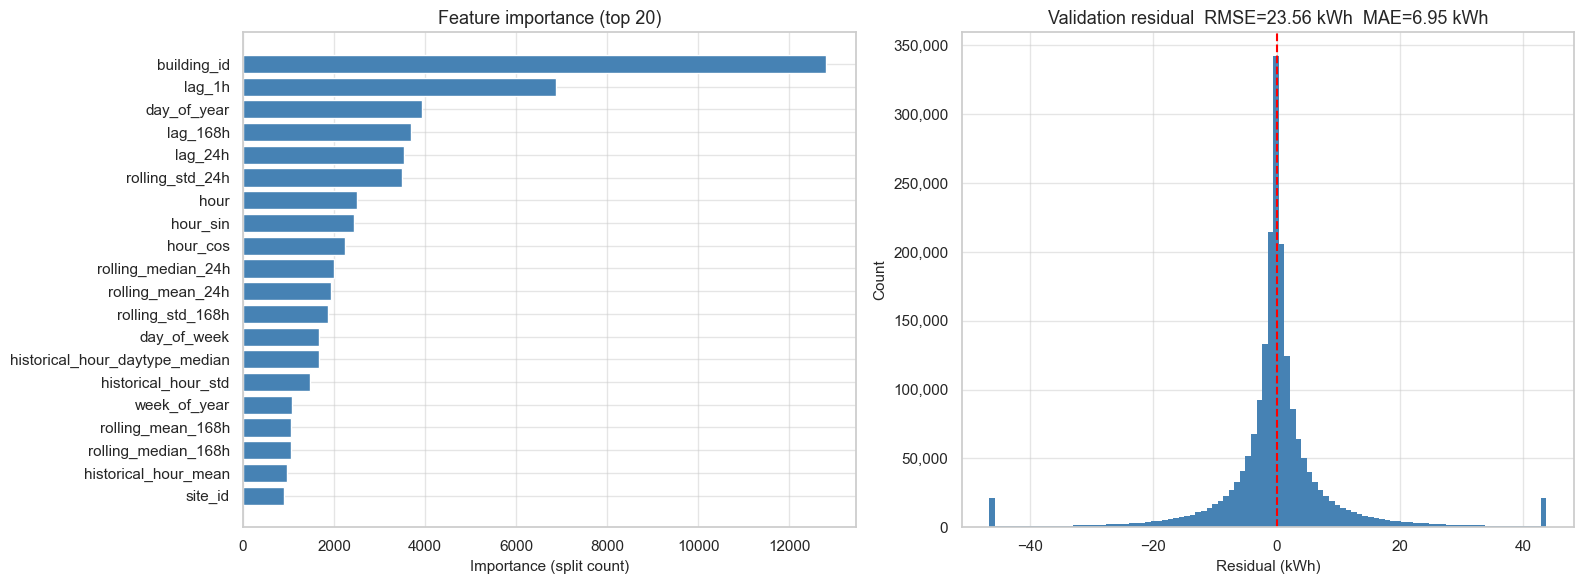

Top 10 features by importance:


,feature,importance
0,building_id,12817
1,lag_1h,6881
2,day_of_year,3936
3,lag_168h,3680
4,lag_24h,3543
5,rolling_std_24h,3498
6,hour,2505
7,hour_sin,2442
8,hour_cos,2246
9,rolling_median_24h,2000


In [7]:
importance = (
    pd.DataFrame({
        'feature'   : model.feature_name_,
        'importance': model.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

resid_val = y_val.values - val_pred
lo, hi    = np.percentile(resid_val, 1), np.percentile(resid_val, 99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = importance.head(20)
axes[0].barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
axes[0].set_title('Feature importance (top 20)')
axes[0].set_xlabel('Importance (split count)')

axes[1].hist(np.clip(resid_val, lo, hi), bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
title_str = f'Validation residual  RMSE={val_rmse:.2f} kWh  MAE={val_mae:.2f} kWh'
axes[1].set_title(title_str)
axes[1].set_xlabel('Residual (kWh)')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print('Top 10 features by importance:')
display(importance.head(10))

---
## 6. Residuals on Scoring Period

In [8]:
# ── Training residuals — calibrate per-building robust z-score stats ──────────
tr_pred_lgbm = model.predict(X_train)
resid_train = pd.DataFrame({
    'building_id': train_df['building_id'].values,
    'resid': train_df[TARGET_COL].values - tr_pred_lgbm,
})
resid_stats = (
    resid_train
    .groupby('building_id')['resid']
    .agg(
        resid_median='median',
        resid_mad=lambda x: np.median(np.abs(x - np.median(x))),
    )
    .reset_index()
)

# ── Scoring predictions ────────────────────────────────────────────────────────
score_df['pred_lgbm'] = model.predict(X_score)

print('Score period metrics:')
resid = score_df[TARGET_COL].values - score_df['pred_lgbm'].values
score_df['resid_lgbm'] = resid
rmse = (resid ** 2).mean() ** 0.5
mae  = np.abs(resid).mean()
print(f'  LightGBM  RMSE={rmse:.3f} kWh  MAE={mae:.3f} kWh')
with mlflow.start_run(run_id=lgbm_run_id):
    mlflow.log_metrics({'score_rmse': rmse, 'score_mae': mae})

# ── Set as primary for downstream scoring ─────────────────────────────────────
score_df['predicted'] = score_df['pred_lgbm']
score_df['residual']  = score_df['resid_lgbm']
print(f'\nBuildings with MAD = 0   : {(resid_stats["resid_mad"] == 0).sum()}')
print(f'Buildings with MAD = NaN : {resid_stats["resid_mad"].isna().sum()}')

Score period metrics:
  LightGBM  RMSE=19.367 kWh  MAE=6.431 kWh
🏃 View run LightGBM at: http://localhost:5000/#/experiments/1/runs/6a6b30f4dca94b3fb062f54d693e6fb8
🧪 View experiment at: http://localhost:5000/#/experiments/1

Buildings with MAD = 0   : 1
Buildings with MAD = NaN : 5


---
## 7. Per-Building Anomaly Scoring

Each scoring-period residual is z-scored using the building's own training-set residual mean and std.  
Readings where |z| > `ANOMALY_Z` are flagged and assigned a severity level based on |z| magnitude.

| Severity | Condition |
|---|---|
| Low | 3 ≤ \|z\| < 4 |
| Medium | 4 ≤ \|z\| < 6 |
| High | 6 ≤ \|z\| < 10 |
| Critical | \|z\| ≥ 10 |

In [9]:
score_df = score_df.drop(columns=['resid_median', 'resid_mad'], errors='ignore')
score_df = score_df.merge(resid_stats, on='building_id', how='left')

# Robust z-score: (x - median) / (1.4826 * MAD)
# 1.4826 makes MAD consistent with std for Gaussian residuals.
# MAD_FLOOR prevents division instability for near-constant buildings.
MAD_SCALE = 1.4826
MAD_FLOOR = 1e-3
safe_mad = (score_df['resid_mad'] * MAD_SCALE).clip(lower=MAD_FLOOR)
score_df['residual_z']    = (score_df['residual'] - score_df['resid_median']) / safe_mad
score_df['anomaly_score'] = score_df['residual_z'].abs()
score_df['is_anomaly']    = score_df['anomaly_score'] > ANOMALY_Z
score_df['direction']     = np.where(
    score_df['residual_z'] >  ANOMALY_Z, 'over',
    np.where(score_df['residual_z'] < -ANOMALY_Z, 'under', 'normal')
)

# Severity — symmetric, based solely on |z| magnitude
SEV_THRESHOLDS = [(10.0, 'Critical'), (6.0, 'High'), (4.0, 'Medium'), (3.0, 'Low')]
score_df['severity'] = np.select(
    [score_df['anomaly_score'] >= t for t, _ in SEV_THRESHOLDS],
    [s for _, s in SEV_THRESHOLDS],
    default='normal',
)

n_total   = len(score_df)
n_anomaly = score_df['is_anomaly'].sum()
n_over    = (score_df['direction'] == 'over').sum()
n_under   = (score_df['direction'] == 'under').sum()

print(f'Scoring rows       : {n_total:,}')
print(f'Anomalies flagged  : {n_anomaly:,}  ({n_anomaly/n_total:.2%})')
print(f'  Over-consumption : {n_over:,}  ({n_over/n_total:.2%})')
print(f'  Under-consumption: {n_under:,}  ({n_under/n_total:.2%})')

print('\nSeverity breakdown:')
sev_order  = ['Critical', 'High', 'Medium', 'Low']
sev_counts = (
    score_df[score_df['is_anomaly']]['severity']
    .value_counts()
    .reindex(sev_order)
    .fillna(0)
    .astype(int)
)
for sev, cnt in sev_counts.items():
    print(f'  {sev:8s}: {cnt:,}  ({cnt / n_anomaly:.1%})')

top_buildings = (
    score_df[score_df['is_anomaly']]
    .groupby(['building_id', 'site_id', 'primaryspaceusage'])
    .agg(
        anomaly_count =('is_anomaly',     'sum'),
        mean_z        =('anomaly_score',  'mean'),
        max_z         =('anomaly_score',  'max'),
        n_critical    =('severity', lambda x: (x == 'Critical').sum()),
        n_high        =('severity', lambda x: (x == 'High').sum()),
    )
    .sort_values('anomaly_count', ascending=False)
    .head(20)
    .reset_index()
)
print('\nTop 20 buildings by anomaly count:')
display(top_buildings)

Scoring rows       : 3,066,457
Anomalies flagged  : 180,021  (5.87%)
  Over-consumption : 101,788  (3.32%)
  Under-consumption: 78,233  (2.55%)

Severity breakdown:
  Critical: 11,799  (6.6%)
  High    : 25,714  (14.3%)
  Medium  : 58,148  (32.3%)
  Low     : 84,360  (46.9%)

Top 20 buildings by anomaly count:


,building_id,site_id,primaryspaceusage,anomaly_count,mean_z,max_z,n_critical,n_high
0,Fox_education_Henrietta,Fox,Education,921,9.368839,46.839954,351.0,242.0
1,Peacock_assembly_Socorro,Peacock,Entertainment/public assembly,714,6.230253,36.061428,89.0,151.0
2,Lamb_industrial_Enrique,Lamb,Manufacturing/industrial,688,8.725045,30.334861,221.0,192.0
3,Cockatoo_assembly_Valencia,Cockatoo,Entertainment/public assembly,672,5.849579,12.537358,40.0,241.0
4,Eagle_education_Luther,Eagle,Education,671,4.966734,47.299700,19.0,99.0
5,Rat_education_Francisca,Rat,Education,670,6.022131,40.990848,63.0,162.0
6,Rat_education_Vicky,Rat,Education,661,7.115170,27.789363,120.0,252.0
7,Rat_public_Fredrick,Rat,Public services,655,6.524808,48.825199,85.0,193.0
8,Lamb_assembly_Rosa,Lamb,Entertainment/public assembly,642,8.638907,40.107891,201.0,184.0
9,Eagle_education_Brianne,Eagle,Education,600,5.456165,23.380907,58.0,77.0


---
## 8. Threshold Analysis

,z_threshold,anomaly_count,anomaly_rate_%
0,2.0,401494,13.109306
1,2.5,262846,8.582267
2,3.0,180021,5.877922
3,3.5,128943,4.210158
4,4.0,95661,3.123457
5,5.0,57396,1.874055


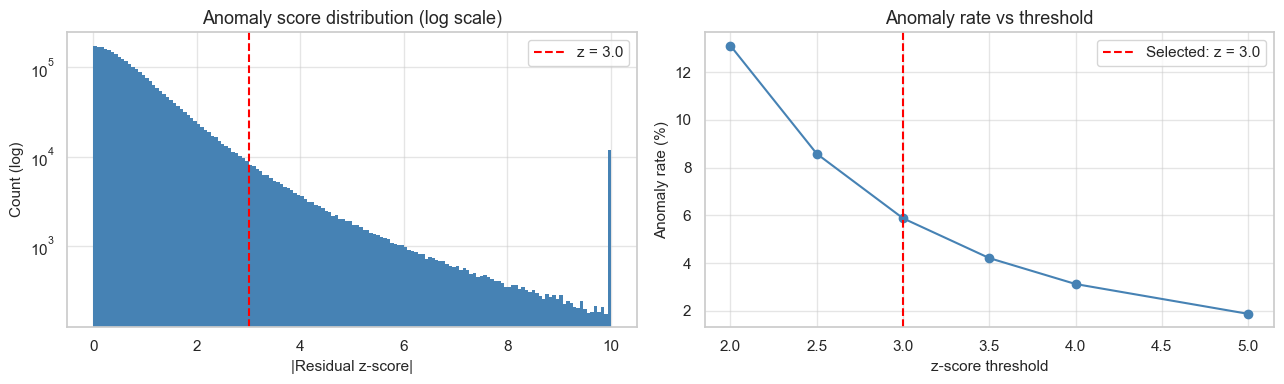

In [10]:
z_scores = score_df['anomaly_score'].dropna()

thresholds = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
thresh_rows = []
for z in thresholds:
    n = (z_scores > z).sum()
    thresh_rows.append({'z_threshold': z, 'anomaly_count': n,
                        'anomaly_rate_%': n / len(z_scores) * 100})
thresh_df = pd.DataFrame(thresh_rows)
display(thresh_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

z_scores.clip(0, 10).hist(ax=axes[0], bins=150, color='steelblue', edgecolor='none', log=True)
axes[0].axvline(ANOMALY_Z, color='red', linestyle='--', linewidth=1.5, label=f'z = {ANOMALY_Z}')
axes[0].set_title('Anomaly score distribution (log scale)')
axes[0].set_xlabel('|Residual z-score|')
axes[0].set_ylabel('Count (log)')
axes[0].legend()

axes[1].plot(thresh_df['z_threshold'], thresh_df['anomaly_rate_%'], marker='o', color='steelblue')
axes[1].axvline(ANOMALY_Z, color='red', linestyle='--', linewidth=1.5, label=f'Selected: z = {ANOMALY_Z}')
axes[1].set_title('Anomaly rate vs threshold')
axes[1].set_xlabel('z-score threshold')
axes[1].set_ylabel('Anomaly rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9. Stage 1 Comparison

Stage 1 masked `spike_extreme_reading` and `near_zero_flatline` before Stage 2, so Stage 3 never scores those timestamps.
This section checks recall against Stage 1's remaining (non-masked) point anomalies and quantifies Stage 3's exclusive new discoveries.

In [11]:
stage1 = pd.read_parquet(STAGE1_PATH)
stage1['timestamp'] = pd.to_datetime(stage1['timestamp'])

NON_MASKED = {'missing_reading', 'zero_reading', 'negative_reading',
              'long_missing_run', 'long_zero_run', 'flatline'}

s1_in_scope = stage1[
    stage1['anomaly_type'].isin(NON_MASKED) &
    stage1['building_id'].isin(set(score_df['building_id'])) &
    (stage1['timestamp'] > VAL_END)
].copy()

s1_pts = set(zip(s1_in_scope['building_id'], s1_in_scope['timestamp']))
s3_pts = set(zip(
    score_df.loc[score_df['is_anomaly'], 'building_id'],
    score_df.loc[score_df['is_anomaly'], 'timestamp'],
))

overlap = s1_pts & s3_pts
s3_only = s3_pts - s1_pts
s1_only = s1_pts - s3_pts

print(f'Stage 1 non-masked anomalies (scoring period): {len(s1_pts):,}')
print(f'Stage 3 flagged points                        : {len(s3_pts):,}')
print(f'Overlap (both agree)                          : {len(overlap):,}')
print(f'Stage 3 exclusive (new discoveries)           : {len(s3_only):,}  '
      f'({len(s3_only)/max(len(s3_pts), 1):.1%} of S3 flags)')
print(f'Stage 1 only (not caught by S3)               : {len(s1_only):,}')
print('\nNote: missing_reading rows are NaN consumption, absent from Stage 3 by design.')

type_recall = []
for atype in sorted(NON_MASKED):
    sub = s1_in_scope[s1_in_scope['anomaly_type'] == atype]
    pts = set(zip(sub['building_id'], sub['timestamp']))
    caught = len(pts & s3_pts)
    type_recall.append({
        'anomaly_type' : atype,
        'stage1_count' : len(pts),
        'caught_by_s3' : caught,
        'recall'       : caught / max(len(pts), 1),
    })
display(
    pd.DataFrame(type_recall)
    .sort_values('stage1_count', ascending=False)
    .reset_index(drop=True)
    .style.format({'recall': '{:.1%}'})
)

Stage 1 non-masked anomalies (scoring period): 9,952
Stage 3 flagged points                        : 180,021
Overlap (both agree)                          : 2,115
Stage 3 exclusive (new discoveries)           : 177,906  (98.8% of S3 flags)
Stage 1 only (not caught by S3)               : 7,837

Note: missing_reading rows are NaN consumption, absent from Stage 3 by design.


,anomaly_type,stage1_count,caught_by_s3,recall
0,flatline,5447,2115,38.8%
1,long_missing_run,2355,0,0.0%
2,missing_reading,2150,0,0.0%
3,long_zero_run,0,0,0.0%
4,negative_reading,0,0,0.0%
5,zero_reading,0,0,0.0%


---
## 10. Visualization

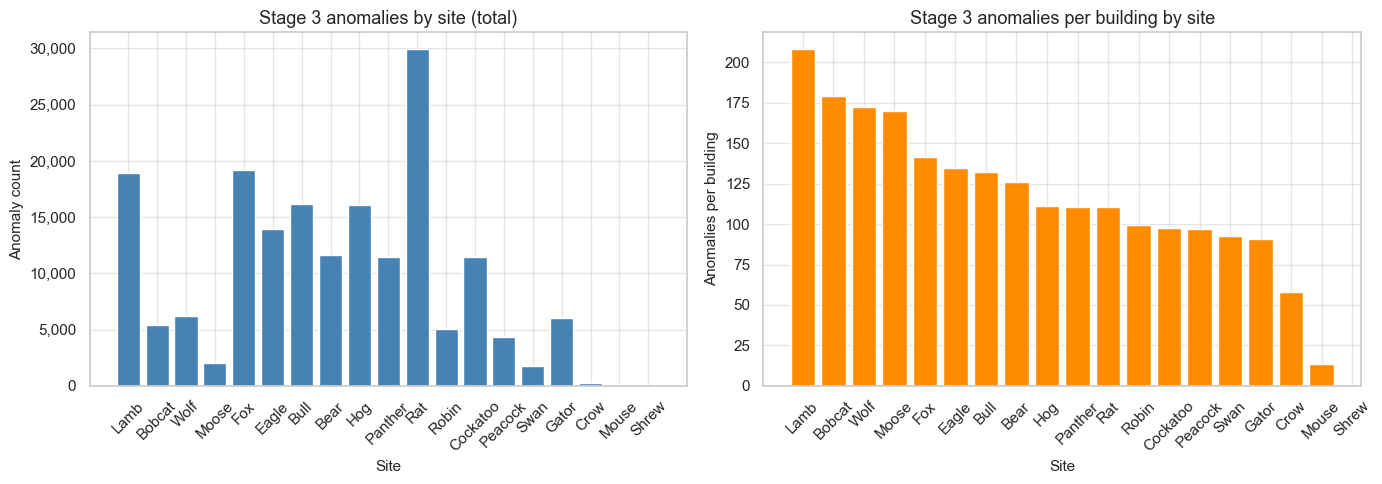

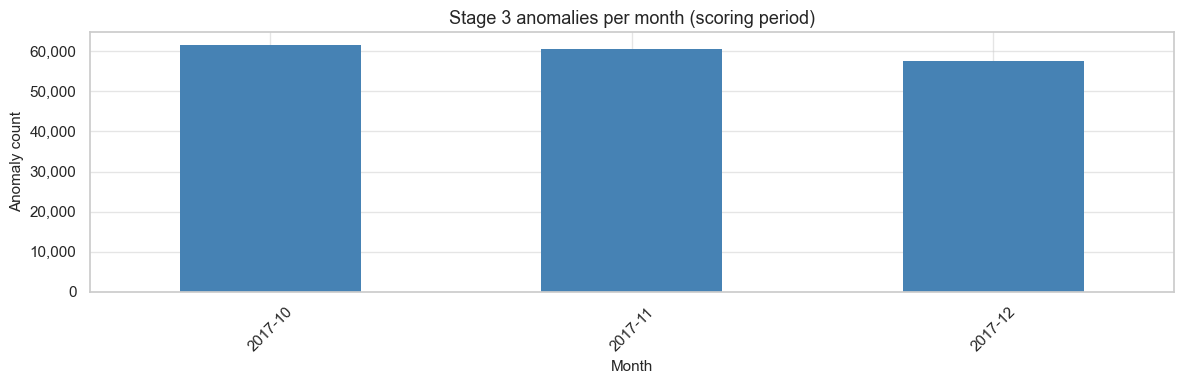

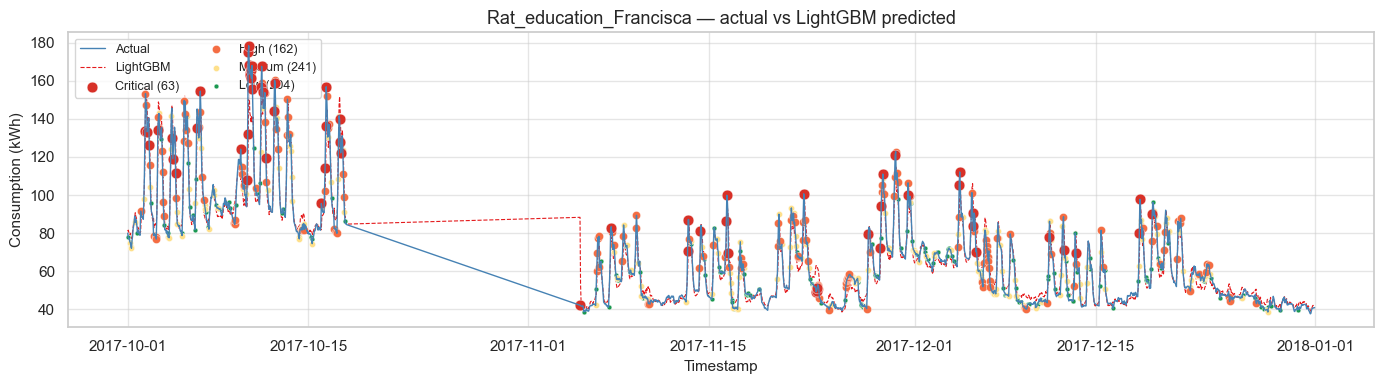

In [15]:
# Site-level anomaly summary
site_anom = (
    score_df[score_df['is_anomaly']]
    .groupby('site_id')
    .agg(n_anomalies=('is_anomaly', 'sum'), n_buildings=('building_id', 'nunique'))
    .assign(per_building=lambda d: d['n_anomalies'] / d['n_buildings'])
    .sort_values('per_building', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(site_anom['site_id'], site_anom['n_anomalies'], color='steelblue')
axes[0].set_title('Stage 3 anomalies by site (total)')
axes[0].set_xlabel('Site')
axes[0].set_ylabel('Anomaly count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(site_anom['site_id'], site_anom['per_building'], color='darkorange')
axes[1].set_title('Stage 3 anomalies per building by site')
axes[1].set_xlabel('Site')
axes[1].set_ylabel('Anomalies per building')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Monthly trend
monthly = (
    score_df
    .assign(month_year=score_df['timestamp'].dt.to_period('M'))
    .groupby('month_year')['is_anomaly']
    .sum()
)

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Stage 3 anomalies per month (scoring period)')
ax.set_xlabel('Month')
ax.set_ylabel('Anomaly count')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# Building: actual vs LightGBM prediction, anomalies coloured by severity
SEV_STYLE = {
    'Critical': {'color': '#d73027', 's': 60, 'zorder': 8},
    'High':     {'color': '#f46d43', 's': 35, 'zorder': 7},
    'Medium':   {'color': '#fee08b', 's': 20, 'zorder': 6},
    'Low':      {'color': '#1a9850', 's': 12, 'zorder': 5},
}

ex_bld  = top_buildings.iloc[5]['building_id']
ex_data = score_df[score_df['building_id'] == ex_bld].sort_values('timestamp')
ex_anom = ex_data[ex_data['is_anomaly']]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ex_data['timestamp'], ex_data[TARGET_COL],
        label='Actual', color='steelblue', linewidth=1.0, zorder=10)
ax.plot(ex_data['timestamp'], ex_data['pred_lgbm'],
        label='LightGBM', color='#e41a1c', linewidth=0.8, linestyle='--')

for sev, style in SEV_STYLE.items():
    pts = ex_anom[ex_anom['severity'] == sev]
    if len(pts):
        ax.scatter(pts['timestamp'], pts[TARGET_COL],
                   label=f'{sev} ({len(pts):,})',
                   edgecolors='white', linewidths=0.3, **style)

ax.set_title(f'{ex_bld} — actual vs LightGBM predicted')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Consumption (kWh)')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

---
## 11. Export

In [13]:
EXPORT_COLS = [
    'building_id', 'timestamp', 'consumption',
    'predicted', 'pred_lgbm',
    'residual', 'residual_z', 'anomaly_score', 'severity', 'direction', 'is_anomaly',
]
for col in ['site_id', 'primaryspaceusage', 'sqm']:
    if col in score_df.columns:
        EXPORT_COLS.append(col)

export_df = score_df[[c for c in EXPORT_COLS if c in score_df.columns]].copy()
export_df['is_anomaly'] = export_df['is_anomaly'].astype(bool)

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
export_df.to_parquet(STAGE3_OUT, index=False)

print(f'Exported {len(export_df):,} rows → {STAGE3_OUT}')
print(f'Model          : {BEST_MODEL}')
print(f'Anomaly rate   : {export_df["is_anomaly"].mean():.2%}')
print(f'Anomaly count  : {export_df["is_anomaly"].sum():,}')
sev_order = ['Critical', 'High', 'Medium', 'Low']
print(export_df[export_df['is_anomaly']]['severity'].value_counts().reindex(sev_order).to_string())

Exported 3,066,457 rows → ..\..\data\processed\anomaly-detection\stage3_residual_anomalies.parquet
Model          : LightGBM
Anomaly rate   : 5.87%
Anomaly count  : 180,021
severity
Critical    11799
High        25714
Medium      58148
Low         84360


---
## 12. Interpretation

*(Run the notebook and fill in: overall anomaly rate, top buildings and sites, overlap with Stage 1, Stage 3-exclusive discoveries, feature importance insights, and recommendations for Stage 4 review.)*